<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/54_adaboost_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [210]:
import pandas as pd
import numpy as np
from  mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt


In [211]:
df= pd.DataFrame()

In [212]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [213]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

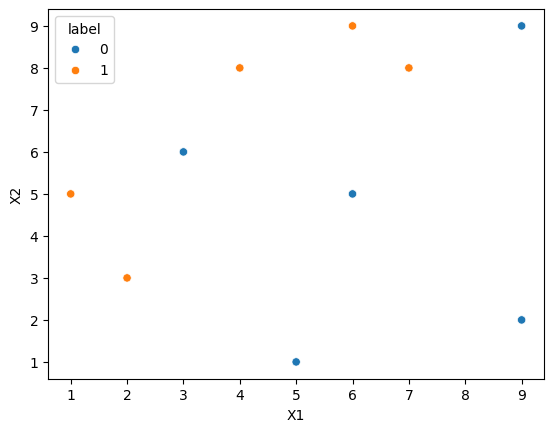

In [214]:
sns.scatterplot(x=df["X1"],y=df["X2"], hue=df["label"])

In [215]:
df["weoghts"]=1/df.shape[0]

In [216]:
df

,X1,X2,label,weoghts
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [217]:
dt1=DecisionTreeClassifier(max_depth=1)

In [218]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [219]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

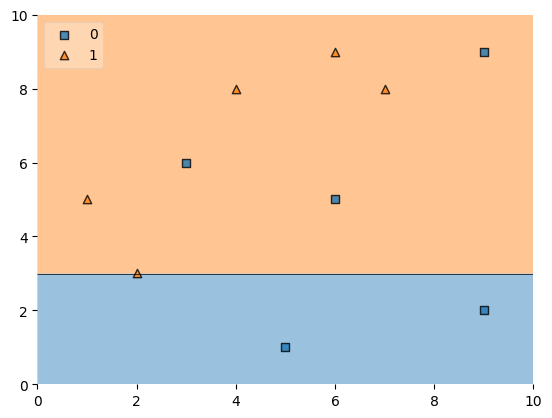

In [220]:
plot_decision_regions(X,y,dt1,legend=2)

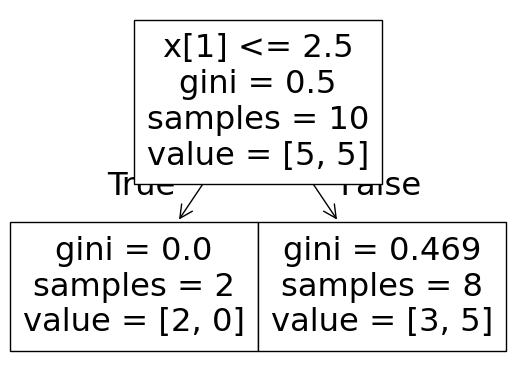

In [221]:
plot_tree(dt1)
plt.show()

In [222]:
df["y_pred"]=dt1.predict(X)

In [223]:
df

,X1,X2,label,weoghts,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [224]:
def calculate_weight(error):
  return 0.5*np.log((1-error)/(error+0.000001))

In [225]:
alpha1=calculate_weight(0.3)

In [226]:
alpha1

np.float64(0.42364726352971294)

In [227]:
def update_row_weights(row,alpha):
  if(row["label"]==row["y_pred"]):
    return row["weoghts"]*np.exp(-alpha)
  else:
     return row["weoghts"]*np.exp(alpha)

In [228]:
df["updated-weight"]=df.apply(update_row_weights,axis=1,args=(alpha1,))

In [229]:
df

,X1,X2,label,weoghts,y_pred,updated-weight
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,1,0.152752
3,4,8,1,0.1,1,0.065465
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,1,0.065465
6,6,5,0,0.1,1,0.152752
7,7,8,1,0.1,1,0.065465
8,9,9,0,0.1,1,0.152752
9,9,2,0,0.1,0,0.065465


In [230]:
df['nomalized_weights'] = df['updated-weight']/df['updated-weight'].sum()

In [231]:
df

,X1,X2,label,weoghts,y_pred,updated-weight,nomalized_weights
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,1,0.152752,0.166666
3,4,8,1,0.1,1,0.065465,0.071429
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,1,0.065465,0.071429
6,6,5,0,0.1,1,0.152752,0.166666
7,7,8,1,0.1,1,0.065465,0.071429
8,9,9,0,0.1,1,0.152752,0.166666
9,9,2,0,0.1,0,0.065465,0.071429


In [232]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [233]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [234]:
df

,X1,X2,label,weoghts,y_pred,updated-weight,nomalized_weights,cumsum_upper
0,1,5,1,0.1,1,0.065465,0.071429,0.071429
1,2,3,1,0.1,1,0.065465,0.071429,0.142857
2,3,6,0,0.1,1,0.152752,0.166666,0.309524
3,4,8,1,0.1,1,0.065465,0.071429,0.380952
4,5,1,0,0.1,0,0.065465,0.071429,0.452381
5,6,9,1,0.1,1,0.065465,0.071429,0.523810
6,6,5,0,0.1,1,0.152752,0.166666,0.690476
7,7,8,1,0.1,1,0.065465,0.071429,0.761905
8,9,9,0,0.1,1,0.152752,0.166666,0.928571
9,9,2,0,0.1,0,0.065465,0.071429,1.000000


In [235]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [236]:
df

,X1,X2,label,weoghts,y_pred,updated-weight,nomalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065465,0.071429,0.071429,0.000000
1,2,3,1,0.1,1,0.065465,0.071429,0.142857,0.071429
2,3,6,0,0.1,1,0.152752,0.166666,0.309524,0.142857
3,4,8,1,0.1,1,0.065465,0.071429,0.380952,0.309524
4,5,1,0,0.1,0,0.065465,0.071429,0.452381,0.380952
5,6,9,1,0.1,1,0.065465,0.071429,0.523810,0.452381
6,6,5,0,0.1,1,0.152752,0.166666,0.690476,0.523810
7,7,8,1,0.1,1,0.065465,0.071429,0.761905,0.690476
8,9,9,0,0.1,1,0.152752,0.166666,0.928571,0.761905
9,9,2,0,0.1,0,0.065465,0.071429,1.000000,0.928571


In [237]:
df[['X1','X2','label','weoghts','y_pred','updated-weight','cumsum_lower','cumsum_upper']]

,X1,X2,label,weoghts,y_pred,updated-weight,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065465,0.000000,0.071429
1,2,3,1,0.1,1,0.065465,0.071429,0.142857
2,3,6,0,0.1,1,0.152752,0.142857,0.309524
3,4,8,1,0.1,1,0.065465,0.309524,0.380952
4,5,1,0,0.1,0,0.065465,0.380952,0.452381
5,6,9,1,0.1,1,0.065465,0.452381,0.523810
6,6,5,0,0.1,1,0.152752,0.523810,0.690476
7,7,8,1,0.1,1,0.065465,0.690476,0.761905
8,9,9,0,0.1,1,0.152752,0.761905,0.928571
9,9,2,0,0.1,0,0.065465,0.928571,1.000000


In [238]:
def create_new_dataset(df):
  indexs=[]
  for i in range(df.shape[0]):
    num=np.random.random()

    for index,row in df.iterrows():

      if(row["cumsum_upper"]>num and row["cumsum_lower"]<num):
        indexs.append(index)
  return indexs



In [239]:
index_values=create_new_dataset(df)
index_values

[1, 7, 9, 6, 6, 7, 9, 7, 2, 2]

In [240]:
second_df =df.iloc[index_values,[0,1,2,3]]

In [241]:
second_df

,X1,X2,label,weoghts
1,2,3,1,0.1
7,7,8,1,0.1
9,9,2,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1
2,3,6,0,0.1


In [242]:
dt2=DecisionTreeClassifier(max_depth=1)

In [243]:
X=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [244]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [245]:
y_pred2=dt2.predict(X)

In [246]:
second_df["y_pred"]=y_pred2

In [247]:
second_df

,X1,X2,label,weoghts,y_pred
1,2,3,1,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,0
7,7,8,1,0.1,1
2,3,6,0,0.1,0
2,3,6,0,0.1,0


<Axes: >

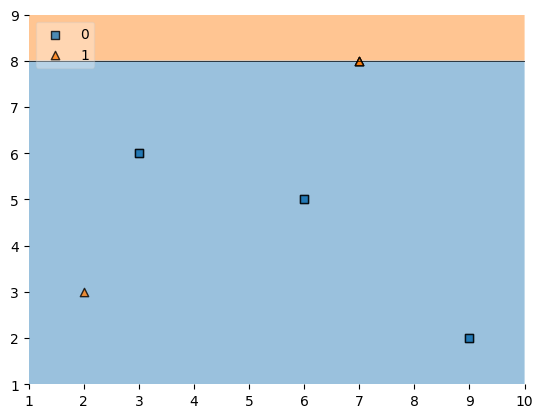

In [248]:
plot_decision_regions(X,y,dt2,legend=2)

In [249]:
alpha2=calculate_weight(0.1)

In [250]:
alpha2

np.float64(1.0986072886931095)

In [251]:
second_df["updated-weight"]=df.apply(update_row_weights,axis=1,args=(alpha2,))

In [252]:
second_df

,X1,X2,label,weoghts,y_pred,updated-weight
1,2,3,1,0.1,0,0.033333
7,7,8,1,0.1,1,0.033333
9,9,2,0,0.1,0,0.033333
6,6,5,0,0.1,0,0.299999
6,6,5,0,0.1,0,0.299999
7,7,8,1,0.1,1,0.033333
9,9,2,0,0.1,0,0.033333
7,7,8,1,0.1,1,0.033333
2,3,6,0,0.1,0,0.299999
2,3,6,0,0.1,0,0.299999


In [253]:
second_df['nomalized_weights'] = second_df['updated-weight']/second_df['updated-weight'].sum()

In [254]:
second_df

,X1,X2,label,weoghts,y_pred,updated-weight,nomalized_weights
1,2,3,1,0.1,0,0.033333,0.023810
7,7,8,1,0.1,1,0.033333,0.023810
9,9,2,0,0.1,0,0.033333,0.023810
6,6,5,0,0.1,0,0.299999,0.214285
6,6,5,0,0.1,0,0.299999,0.214285
7,7,8,1,0.1,1,0.033333,0.023810
9,9,2,0,0.1,0,0.033333,0.023810
7,7,8,1,0.1,1,0.033333,0.023810
2,3,6,0,0.1,0,0.299999,0.214285
2,3,6,0,0.1,0,0.299999,0.214285


In [255]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

second_df[['X1','X2','label','weoghts','y_pred','updated-weight','cumsum_lower','cumsum_upper']]



,X1,X2,label,weoghts,y_pred,updated-weight,cumsum_lower,cumsum_upper
1,2,3,1,0.1,0,0.033333,0.000000,0.023810
7,7,8,1,0.1,1,0.033333,0.023810,0.047619
9,9,2,0,0.1,0,0.033333,0.047619,0.071429
6,6,5,0,0.1,0,0.299999,0.071429,0.285715
6,6,5,0,0.1,0,0.299999,0.285715,0.500000
7,7,8,1,0.1,1,0.033333,0.500000,0.523810
9,9,2,0,0.1,0,0.033333,0.523810,0.547619
7,7,8,1,0.1,1,0.033333,0.547619,0.571429
2,3,6,0,0.1,0,0.299999,0.571429,0.785715
2,3,6,0,0.1,0,0.299999,0.785715,1.000000


In [256]:
index_values=create_new_dataset(second_df)
print(index_values)

t_df =second_df.iloc[index_values,[0,1,2,3]]

[2, 6, 6, 2, 6, 2, 6, 6, 6, 2]


In [257]:
t_df

,X1,X2,label,weoghts
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1


In [258]:
dt3=DecisionTreeClassifier(max_depth=1)

In [259]:
X=t_df.iloc[:,0:2].values
y=t_df.iloc[:,2].values
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [260]:
y_pred3=dt3.predict(X)

In [261]:
t_df["y_pred3"]=y_pred3

In [262]:
t_df

,X1,X2,label,weoghts,y_pred3
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0


In [263]:
alpha3=calculate_weight(0)

In [265]:
alpha3

np.float64(6.907755278982137)

In [266]:
print(alpha1,alpha2,alpha3)

0.42364726352971294 1.0986072886931095 6.907755278982137


**Prediction**

In [272]:
query = np.array([5,1]).reshape(1,2)
dt1.predict(query)

array([0])

In [273]:
dt2.predict(query)

array([0])

In [274]:
dt3.predict(query)

array([0])

In [276]:
np.sign(alpha1*0 + alpha2*(0) + alpha3*(0))

np.float64(0.0)